# なぜ反応器を 3 段にしたか — 単段の限界から多段化までの物語

本ノートは反応器設計の変遷を**順を追って**示す。出発点は\\
**径方向流になる前の「単段の断熱固定床」**であり、そこから現在の **径方向流 3 段(段間再加熱)** に
至る理由を、段数 1/2/3/4 の比較で定量的に説明する。

物語の筋:

1. **出発点(§1)**: 当初の反応器は単段の断熱固定床。強吸熱 PDH では単通転化率が**断熱平衡に頭打ち**。
2. **圧損ピボット(§2)**: 0.5 bar 低圧で軸流深床は圧力損失で不成立 → **径方向流**へ。
   ただし**単段の転化率天井(~28%)は体積でも圧損でもなく『平衡』で決まる**。体積を増やせば天井に届くが超えられない
   (この天井は圧損を考えない当初版にも同じく在った=温度低下は隠れていなかった)。
3. **系の破綻(§3)**: 単段の低転化はリサイクルを巨大化し、膜分離フィードを希釈して系全体を不成立にする。
4. **解決(§4)**: 実機 UOP Oleflex に倣い **多段化(段間再加熱)** で各段の平衡をリセットし累積転化率を上げる。
5. **段数決定(§5,§6)**: 1/2/3/4 段を比較。**総合収率は単通選択率で律速**されるため、段数を増やすほど
   転化率は上がるが選択率(=総合収率)は下がる。系が成立する**最小段数 = 3** が最適。

> 反応器は `units/reactors/radial_flow.py` (純 Python, scipy ODE)。HYSYS 不要。\\
> 数値は説明用の代表設計点。確定値は再最適化後に更新する【確認中】。


In [1]:
import os, sys, math
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from units.reactors.radial_flow import (
    RadialDesignVars, simulate_radial_flow_reactor_system,
    simulate_radial_multibed_reactor_system,
)
from units.reactors.swing import FeedStream, FixedParams

fixed = FixedParams()
# 純プロパン基準 (レポート Table 4-4 と整合)。確定設計点の数値は再最適化後【確認中】。
feed  = FeedStream(F_in={'A': 6400.0, 'B': 0.0, 'C': 0.0, 'D': 0.0, 'E': 0.0, 'F': 0.0},
                   T_feed=314.15, P_in=50000.0)
T_IN  = 939.0
# 各段共通の径方向流ジオメトリ (1-4 段が全て圧損可行な代表値)
design = RadialDesignVars(T_in=T_IN, t_cyc=17.0, D_inner=9.0, bed_thickness=0.5, H=30.0)

print(f'純プロパン基準, T_in={T_IN:.0f}K, P=0.5bar')
print(f'径方向流ジオメトリ(各段共通): D_inner=9m  Δr=0.5m  H=30m  t_cyc=17min')
print('※数値は説明用の代表設計点、確定は再最適化後【確認中】')

純プロパン基準, T_in=939K, P=0.5bar
径方向流ジオメトリ(各段共通): D_inner=9m  Δr=0.5m  H=30m  t_cyc=17min
※数値は説明用の代表設計点、確定は再最適化後【確認中】


## §1. 出発点 — 単段の断熱固定床(径方向流以前)

反応器設計は当初、**単段の断熱固定床**として検討された。プロパン脱水素は強い吸熱反応
($\Delta H_{r1}\approx+124$ kJ/mol)であり、断熱床ではガスが流れ方向に自己冷却して**出口温度の
平衡に張り付く**ため、**単通転化率が断熱平衡(~20–28%)で頭打ち**になる。
これは触媒量(体積)を増やしても破れない熱力学的上限である(機構の詳細は
`reactor_conversion_ceiling.ipynb`)。まず単段の到達点を確認する。

In [2]:
r1 = simulate_radial_flow_reactor_system(design, feed, fixed)
print(f'単段(径方向流 断熱床): X={r1.performance.Conversion:.1f}%  '
      f'S={r1.performance.Selectivity:.1f}%  T_out={r1.effluent.T_out_avg-273.15:.0f}C')
print('→ 単段では転化率が断熱平衡に頭打ち。これが出発点の問題。')

単段(径方向流 断熱床): X=19.9%  S=81.3%  T_out=549C
→ 単段では転化率が断熱平衡に頭打ち。これが出発点の問題。


## §2. 圧損による径方向流ピボットと「単段の天井は体積では破れない」

反応平衡を有利にするため反応器は絶対圧 $0.5\,\mathrm{bar}$ の低圧で運転する。現実的な触媒粒径($2\text{--}6\,\mathrm{mm}$)では
**軸流深床は Ergun 圧損($\Delta P/P>10\%$)で不成立**となるため、薄い環状床を半径方向に通す径方向流へ転換した
(詳細は `reactor_pressure_drop_and_geometry.ipynb`)。

ここで本章の核心を明確にする。**単段断熱床の単通転化率は断熱平衡(~28\%前後)で頭打ちであり、これは
体積でも圧力損失でもなく『平衡』で決まる**。触媒量(床厚 $\Delta r$)を増やせば天井(~28\%)には漸近するが、
\textbf{それを超えることは原理的にできない}。そして\textbf{この~28\%の天井は圧損を考えない当初版にも同じく存在していた}
——温度低下(断熱冷却)はエネルギー収支に最初から入っており、隠れていたわけではない。

したがって、

> **単段の転化率天井(~28\%)を超える唯一の方法は、各段で平衡をリセットする多段化(段間再加熱)である。**

圧損は「単段が天井に届くか」には影響するが(高流量で厚床は ΔP 超過しうる)、\textbf{天井そのものを動かさない}。
多段化は圧損対策ではなく、\textbf{平衡で決まる単段天井を超えるための手段}である。下で体積掃引により天井を確認する。

In [3]:
import math
# 単段 径方向床の体積掃引: 床厚 Δr(=体積)を増やすと転化率は断熱平衡天井に漸近するが超えない
print('単段 径方向床の体積掃引 (D_inner=9m, H=30m, 純プロパン):')
print('  Δr[m]  V_cat[m3]   X[%]   ΔP/P[%]  penalty')
for dr in (0.5, 1.0, 1.5, 2.0):
    d = RadialDesignVars(T_in=T_IN, t_cyc=17.0, D_inner=9.0, bed_thickness=dr, H=30.0)
    r = simulate_radial_flow_reactor_system(d, feed, fixed)
    V = math.pi * ((4.5 + dr)**2 - 4.5**2) * 30.0 * 0.5
    print(f'   {dr:.1f}   {V:7.0f}    {r.performance.Conversion:4.1f}    '
          f'{r.equipment.dP_over_P_actual*100:4.1f}    {r.equipment.penalty_reason!r}')
print()
print('→ 体積(Δr)を増やしても単通転化率は断熱平衡天井(~28-30%)で頭打ち、超えられない。')
print('  天井は体積でも圧損でもなく「平衡」で決まる(圧損なしの当初版でも同じ天井)。')
print('  この天井を超える唯一の手段が、各段で平衡をリセットする多段化(段間再加熱)である。')

単段 径方向床の体積掃引 (D_inner=9m, H=30m, 純プロパン):
  Δr[m]  V_cat[m3]   X[%]   ΔP/P[%]  penalty


   0.5       224    19.9     1.3    ''


   1.0       471    25.3     2.5    ''


   1.5       742    27.6     3.5    ''


   2.0      1037    28.7     4.4    ''

→ 体積(Δr)を増やしても単通転化率は断熱平衡天井(~28-30%)で頭打ち、超えられない。
  天井は体積でも圧損でもなく「平衡」で決まる(圧損なしの当初版でも同じ天井)。
  この天井を超える唯一の手段が、各段で平衡をリセットする多段化(段間再加熱)である。


## §3. 単段の低転化が系全体を破綻させる

単段の低い単通転化率は、反応器単体では健全に見えても**リサイクルを通すと下流を破綻させる**。
未反応プロパンが巨大なリサイクル流となり、C3 分離前の**膜分離器フィードがプロパン主体(プロピレン
モル分率 ~18%)まで希釈**される。希薄フィードでは膜のプロピレン回収率が ~30% に留まり、

- (i) C3 スプリッタへの透過側フィード流量がサロゲートモデルの学習域下限を割り込んで**不成立**、
- (ii) 回収されなかったプロピレンがリサイクルで反応器に戻り副生成分に転化して**総合収率が ~46% へ低下**。

つまり単段では「転化率が低すぎて系が回らない」。これを単段では解決できない。
**【確認中: 本節の全系数値(膜回収率・収率等)は再最適化後に更新】**

## §4. 解決 = 多段化(段間再加熱)

実機の低圧 PDH(UOP Oleflex)は径方向流断熱反応器を **3〜4 基直列**に並べ、各反応器の間に
**加熱炉(段間再加熱)**を置いて吸熱で冷えたガスを反応温度へ戻す。各段で平衡がリセットされ、
**累積転化率**が上がる。本設計もこの構成を採り、同一ジオメトリの径方向流断熱床を $N$ 段直列に
接続して各段入口を $T_{\mathrm{in}}$ まで再加熱する(再加熱熱量は加熱炉燃料費に計上)。

数値計算は**時刻同期**で行う(時刻 $t$ ごとに全段を直列積分してから時間平均)。次に段数 $N=1,2,3,4$ を比較する。

In [4]:
rows = []
for n in (1, 2, 3, 4):
    r = simulate_radial_multibed_reactor_system(design, feed, fixed, n_beds=n)
    p, q, e = r.performance, r.equipment, r.effluent
    rows.append(dict(
        stages=n,
        X_cum_pct=round(p.Conversion, 1),
        S_pct=round(p.Selectivity, 1),
        overall_yield_approx_S=round(p.Selectivity, 1),   # 総合収率 ≈ 単通選択率 (リサイクル消尽)
        dP_over_P_pct=round(q.dP_over_P_actual * 100, 1),
        N_reactors=q.N_reactors_total,
        catalyst_t=round(q.Catalyst_Weight_Total / 1000),
        heater_GJ_h=round(e.Q_preheat),
        penalty=q.penalty_reason,
    ))
df = pd.DataFrame(rows)
print(df.to_string(index=False))
print()
print('累積転化率は段数とともに上がる (各段で平衡リセット) が、高転化ほど副反応が進み選択率は下がる。')
print('反応器数・触媒量・加熱炉燃料は段数にほぼ比例して増える。')

 stages  X_cum_pct  S_pct  overall_yield_approx_S  dP_over_P_pct  N_reactors  catalyst_t  heater_GJ_h penalty
      1       19.9   81.3                    81.3            1.3           6         604          520        
      2       36.1   78.0                    78.0            2.9          12        1209          642        
      3       48.5   76.0                    76.0            4.7          18        1813          722        
      4       58.2   74.4                    74.4            6.6          24        2417          778        

累積転化率は段数とともに上がる (各段で平衡リセット) が、高転化ほど副反応が進み選択率は下がる。
反応器数・触媒量・加熱炉燃料は段数にほぼ比例して増える。


## §5. 段数 vs 性能・コストの可視化

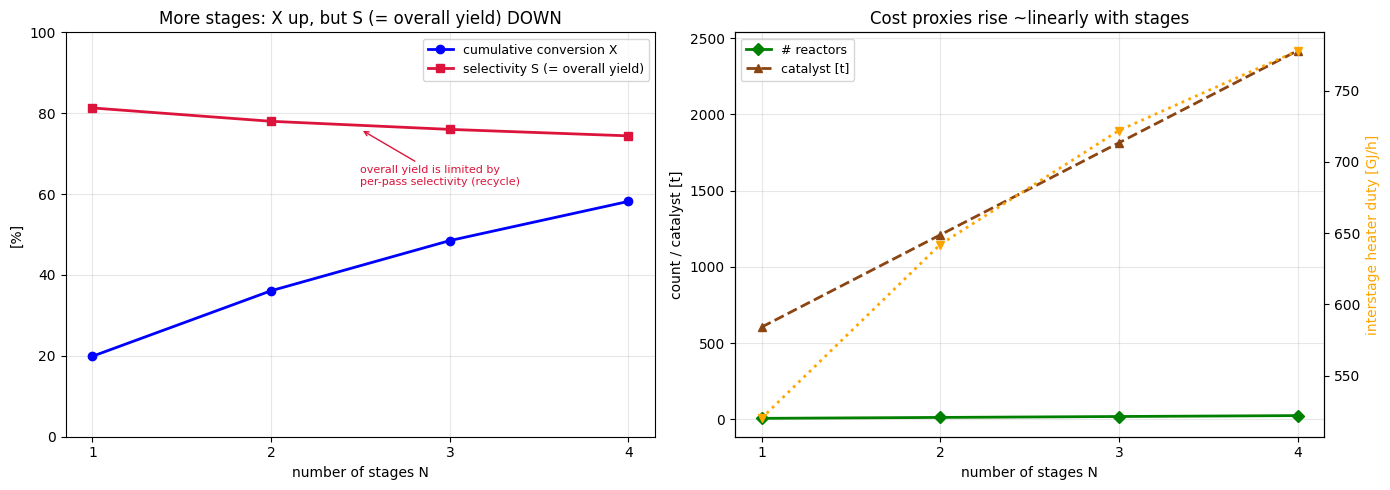

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(df.stages, df.X_cum_pct, 'o-', color='blue', lw=2, label='cumulative conversion X')
ax[0].plot(df.stages, df.S_pct, 's-', color='crimson', lw=2, label='selectivity S (= overall yield)')
ax[0].set_xlabel('number of stages N'); ax[0].set_ylabel('[%]'); ax[0].set_xticks([1,2,3,4])
ax[0].set_title('More stages: X up, but S (= overall yield) DOWN')
ax[0].legend(fontsize=9); ax[0].grid(True, alpha=0.3); ax[0].set_ylim(0, 100)
ax[0].annotate('overall yield is limited by\nper-pass selectivity (recycle)',
               (2.5, df.S_pct.iloc[2]), fontsize=8, color='crimson',
               xytext=(0, -40), textcoords='offset points',
               arrowprops=dict(arrowstyle='->', color='crimson'))

ax2 = ax[1]
ax2.plot(df.stages, df.N_reactors, 'D-', color='green', lw=2, label='# reactors')
ax2.plot(df.stages, df.catalyst_t, '^--', color='saddlebrown', lw=2, label='catalyst [t]')
ax2b = ax2.twinx()
ax2b.plot(df.stages, df.heater_GJ_h, 'v:', color='orange', lw=2, label='heater duty [GJ/h]')
ax2b.set_ylabel('interstage heater duty [GJ/h]', color='orange')
ax2.set_xlabel('number of stages N'); ax2.set_ylabel('count / catalyst [t]'); ax2.set_xticks([1,2,3,4])
ax2.set_title('Cost proxies rise ~linearly with stages')
ax2.legend(fontsize=9, loc='upper left'); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## §6. なぜ 3 段か — 決め手

**鍵となる事実: リサイクル消尽運転では総合収率 ≈ 単通選択率**。\\
プロパンは未反応でもリサイクルされ最終的に転化されるので、**炭素損失はクラッキング(選択率)で決まる**。
つまり総合収率は単通転化率ではなく**単通選択率**で律速される。したがって:

- **段数を増やすほど選択率(=総合収率)は下がる** → 収率の観点では段数は**少ない方が良い**。
- しかし**段数が少なすぎると単通転化率が低く、§3 のリサイクル希釈で系が不成立**になる。

よって最適段数は「**系が成立する最小段数**」。3 段で C3 スプリッタ成立に十分な転化率が確保され、
4 段にしても転化率が過剰になるだけで選択率(総合収率)はさらに下がり、反応器・触媒・加熱炉燃料・
累積圧力損失が増える。3→4 段の増分を見る。

In [6]:
inc = df.copy()
inc['dX'] = inc.X_cum_pct.diff()
inc['dS'] = inc.S_pct.diff()
print(inc[['stages','X_cum_pct','S_pct','dX','dS','dP_over_P_pct','N_reactors','catalyst_t','heater_GJ_h']].to_string(index=False))
print()
d34 = df[df.stages==4].iloc[0]
d33 = df[df.stages==3].iloc[0]
print('3 → 4 段の比較:')
print(f'  累積転化率 {d33.X_cum_pct:.1f}% → {d34.X_cum_pct:.1f}%  (+{d34.X_cum_pct-d33.X_cum_pct:.1f}pt)')
print(f'  選択率(=総合収率) {d33.S_pct:.1f}% → {d34.S_pct:.1f}%  ({d34.S_pct-d33.S_pct:+.1f}pt)  ← 総合収率は下がる')
print(f'  反応器数 {d33.N_reactors} → {d34.N_reactors} 基,  触媒 {d33.catalyst_t} → {d34.catalyst_t} t,  '
      f'加熱炉 {d33.heater_GJ_h} → {d34.heater_GJ_h} GJ/h,  ΔP {d33.dP_over_P_pct:.1f}% → {d34.dP_over_P_pct:.1f}%')
print()
print('→ 4 段は転化率が上がるだけで総合収率(選択率)は下がり、コスト(反応器/触媒/燃料/圧損)が増える。')
print('  3 段で既に系成立に十分 → TAC の観点から 3 段を採用。')
print('  (注: 薄床の確定設計点では 4 段は累積 ΔP が 10% 上限を超えて不成立になる場合もある。)')

 stages  X_cum_pct  S_pct   dX   dS  dP_over_P_pct  N_reactors  catalyst_t  heater_GJ_h
      1       19.9   81.3  NaN  NaN            1.3           6         604          520
      2       36.1   78.0 16.2 -3.3            2.9          12        1209          642
      3       48.5   76.0 12.4 -2.0            4.7          18        1813          722
      4       58.2   74.4  9.7 -1.6            6.6          24        2417          778

3 → 4 段の比較:
  累積転化率 48.5% → 58.2%  (+9.7pt)
  選択率(=総合収率) 76.0% → 74.4%  (-1.6pt)  ← 総合収率は下がる
  反応器数 18 → 24 基,  触媒 1813 → 2417 t,  加熱炉 722 → 778 GJ/h,  ΔP 4.7% → 6.6%

→ 4 段は転化率が上がるだけで総合収率(選択率)は下がり、コスト(反応器/触媒/燃料/圧損)が増える。
  3 段で既に系成立に十分 → TAC の観点から 3 段を採用。
  (注: 薄床の確定設計点では 4 段は累積 ΔP が 10% 上限を超えて不成立になる場合もある。)


## §7. 結論

| 段数 | 累積転化率 | 選択率(≈総合収率) | コスト(反応器/触媒/燃料/ΔP) | 判定 |
|---|---|---|---|---|
| 1 | 低すぎ | 最高 | 最小 | **系が不成立**(リサイクル希釈) |
| 2 | やや低 | 高 | 小 | 系が成立しにくい |
| **3** | **十分** | **良好** | **中** | **採用**(系成立の最小段数) |
| 4 | 過剰 | 低下 | 大 | 収率↓+コスト↑で不利 |

- **総合収率は単通選択率で律速**される(リサイクルが未反応プロパンを消尽)。よって段数は本来少ない方が
  収率に有利だが、少なすぎると単通転化率が低く**リサイクル希釈で系が破綻**する。
- **3 段は系が成立する最小段数**であり、C3 スプリッタ成立に十分な転化率を確保しつつ選択率(総合収率)
  とコストを最良に保つ。4 段は転化率が過剰になるだけで総合収率は下がり、反応器・触媒・加熱炉燃料・
  累積圧力損失が増えるため利得がない。
- 実機 UOP Oleflex の 3〜4 基の下端にも対応する。**→ 3 段を採用**。

> 数値は説明用の代表設計点。確定値・最終的な段数感度は再最適化後に更新する【確認中】。
